# Statistical Distributions in Gendantic

This notebook covers all available statistical distributions and when to use them.

Gendantic uses **numpy** for sampling, giving you:
- Guaranteed statistical properties
- Reproducible results with seeds
- High performance for large datasets

In [1]:
from typing import Annotated

import numpy as np
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field

from gendantic import (
    generate_synthetic_data,
    Normal,
    Uniform,
    Categorical,
    LogNormal,
    Exponential,
    Poisson,
    Beta,
    Binomial,
)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 3)

## Normal Distribution

**Use for**: Salaries, test scores, heights, measurements - anything that clusters around a mean.

Parameters:
- `mean`: Center of the distribution
- `std`: Standard deviation (spread)

Mean: £74,246
Std Dev: £11,592
Min: £45,734, Max: £107,125


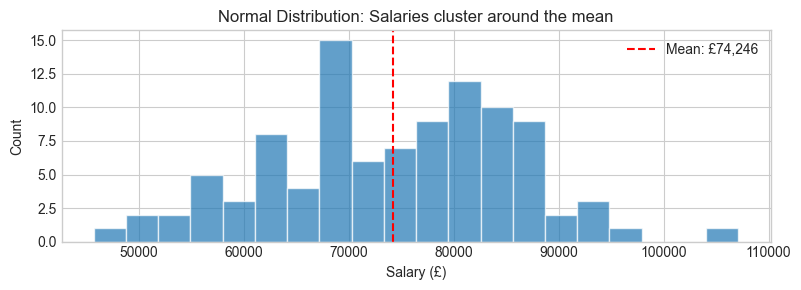

In [2]:
class SalaryData(BaseModel):
    employee_name: str
    salary: Annotated[float, Normal(mean=75000, std=15000)]

salaries = await generate_synthetic_data(SalaryData, count=100, seed=42)

salary_values = [s.salary for s in salaries]
print(f"Mean: £{np.mean(salary_values):,.0f}")
print(f"Std Dev: £{np.std(salary_values):,.0f}")
print(f"Min: £{min(salary_values):,.0f}, Max: £{max(salary_values):,.0f}")

# Plot
plt.figure()
plt.hist(salary_values, bins=20, edgecolor='white', alpha=0.7)
plt.axvline(np.mean(salary_values), color='red', linestyle='--', label=f'Mean: £{np.mean(salary_values):,.0f}')
plt.xlabel('Salary (£)')
plt.ylabel('Count')
plt.title('Normal Distribution: Salaries cluster around the mean')
plt.legend()
plt.tight_layout()
plt.show()

## Uniform Distribution

**Use for**: Ages, random IDs, anything with equal probability across a range.

Parameters:
- `min`: Minimum value
- `max`: Maximum value

Mean: 40.9
Min: 18, Max: 64


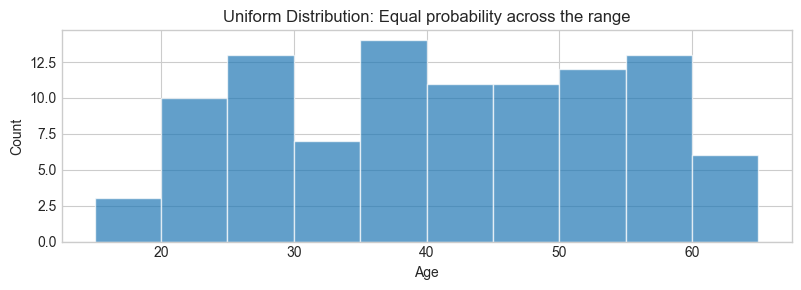

In [3]:
class AgeData(BaseModel):
    person_name: str
    age: Annotated[int, Uniform(min=18, max=65)]

ages = await generate_synthetic_data(AgeData, count=100, seed=42)

age_values = [a.age for a in ages]
print(f"Mean: {np.mean(age_values):.1f}")
print(f"Min: {min(age_values)}, Max: {max(age_values)}")

# Plot
plt.figure()
plt.hist(age_values, bins=range(15, 70, 5), edgecolor='white', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Uniform Distribution: Equal probability across the range')
plt.tight_layout()
plt.show()

## Categorical Distribution

**Use for**: Departments, statuses, regions, types - any discrete categories with specific probabilities.

Parameters:
- `weights`: Dictionary of category to probability (must sum to 1.0)

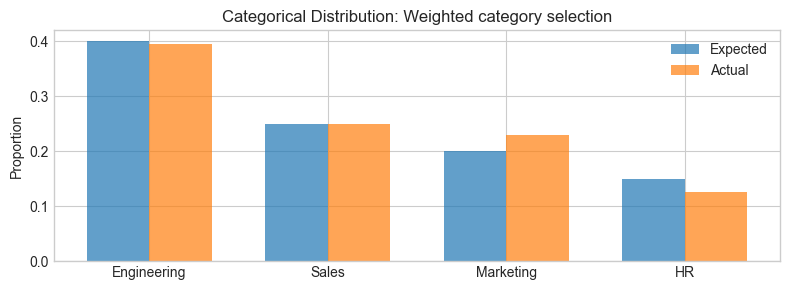

In [4]:
class DepartmentData(BaseModel):
    employee_name: str
    department: Annotated[str, Categorical(weights={
        "Engineering": 0.40,
        "Sales": 0.25,
        "Marketing": 0.20,
        "HR": 0.15,
    })]

departments = await generate_synthetic_data(DepartmentData, count=200, seed=42)

from collections import Counter
counts = Counter(d.department for d in departments)

# Plot
plt.figure()
depts = ['Engineering', 'Sales', 'Marketing', 'HR']
expected = [0.40, 0.25, 0.20, 0.15]
actual = [counts[d]/len(departments) for d in depts]
x = np.arange(len(depts))
width = 0.35
plt.bar(x - width/2, expected, width, label='Expected', alpha=0.7)
plt.bar(x + width/2, actual, width, label='Actual', alpha=0.7)
plt.xticks(x, depts)
plt.ylabel('Proportion')
plt.title('Categorical Distribution: Weighted category selection')
plt.legend()
plt.tight_layout()
plt.show()

## LogNormal Distribution

**Use for**: Incomes, file sizes, prices - right-skewed data where most values are small but some are very large.

Parameters:
- `mean`: Mean of the underlying normal distribution (in log space)
- `sigma`: Standard deviation in log space

Median: £36,255
Mean: £41,976
Note: Mean > Median indicates right skew (a few high earners)


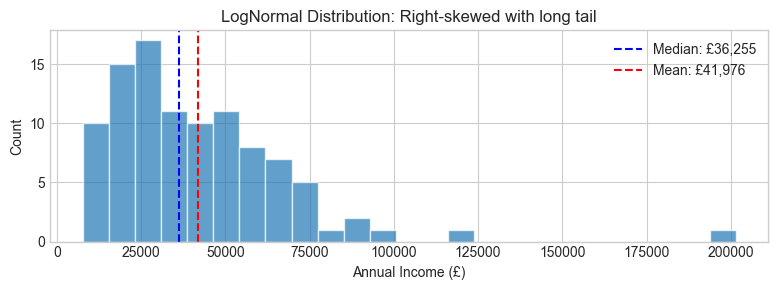

In [5]:
class IncomeData(BaseModel):
    household_id: str
    annual_income: Annotated[float, LogNormal(mean=10.5, sigma=0.8)]  # ~£40k median

incomes = await generate_synthetic_data(IncomeData, count=100, seed=42)

income_values = [i.annual_income for i in incomes]
print(f"Median: £{np.median(income_values):,.0f}")
print(f"Mean: £{np.mean(income_values):,.0f}")
print(f"Note: Mean > Median indicates right skew (a few high earners)")

# Plot
plt.figure()
plt.hist(income_values, bins=25, edgecolor='white', alpha=0.7)
plt.axvline(np.median(income_values), color='blue', linestyle='--', label=f'Median: £{np.median(income_values):,.0f}')
plt.axvline(np.mean(income_values), color='red', linestyle='--', label=f'Mean: £{np.mean(income_values):,.0f}')
plt.xlabel('Annual Income (£)')
plt.ylabel('Count')
plt.title('LogNormal Distribution: Right-skewed with long tail')
plt.legend()
plt.tight_layout()
plt.show()

## Exponential Distribution

**Use for**: Wait times, time between events, decay processes.

Parameters:
- `scale`: Scale parameter (1/rate), equals the mean

Mean: 89.9ms
Median: 60.7ms
95th percentile: 238.6ms


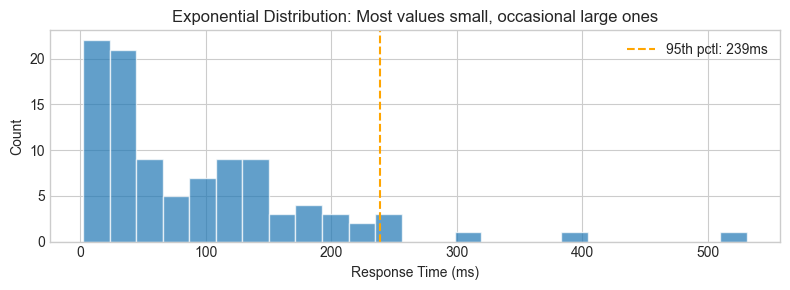

In [6]:
class ResponseTime(BaseModel):
    request_id: str
    response_ms: Annotated[float, Exponential(scale=100)]  # Mean 100ms

responses = await generate_synthetic_data(ResponseTime, count=100, seed=42)

times = [r.response_ms for r in responses]
print(f"Mean: {np.mean(times):.1f}ms")
print(f"Median: {np.median(times):.1f}ms")
print(f"95th percentile: {np.percentile(times, 95):.1f}ms")

# Plot
plt.figure()
plt.hist(times, bins=25, edgecolor='white', alpha=0.7)
plt.axvline(np.percentile(times, 95), color='orange', linestyle='--', label=f'95th pctl: {np.percentile(times, 95):.0f}ms')
plt.xlabel('Response Time (ms)')
plt.ylabel('Count')
plt.title('Exponential Distribution: Most values small, occasional large ones')
plt.legend()
plt.tight_layout()
plt.show()

## Poisson Distribution

**Use for**: Count data - number of events, errors, arrivals in a fixed period.

Parameters:
- `lam`: Lambda (rate/mean number of events)

Mean: 3.1 errors/day


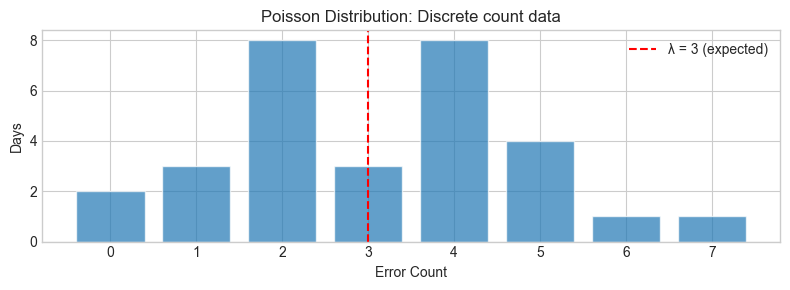

In [7]:
class DailyErrors(BaseModel):
    date: str
    error_count: Annotated[int, Poisson(lam=3)]  # Average 3 errors/day

errors = await generate_synthetic_data(DailyErrors, count=30, seed=42)

error_counts = [e.error_count for e in errors]
print(f"Mean: {np.mean(error_counts):.1f} errors/day")

# Plot
plt.figure()
unique_counts = range(0, max(error_counts) + 1)
frequencies = [error_counts.count(c) for c in unique_counts]
plt.bar(unique_counts, frequencies, edgecolor='white', alpha=0.7)
plt.axvline(3, color='red', linestyle='--', label='λ = 3 (expected)')
plt.xlabel('Error Count')
plt.ylabel('Days')
plt.title('Poisson Distribution: Discrete count data')
plt.legend()
plt.tight_layout()
plt.show()

## Beta Distribution

**Use for**: Probabilities, percentages, rates - values bounded between 0 and 1.

Parameters:
- `alpha`: Shape parameter (higher = more weight toward 1)
- `beta`: Shape parameter (higher = more weight toward 0)

Common shapes:
- `alpha=beta=1`: Uniform on [0,1]
- `alpha>beta`: Skewed toward 1
- `alpha<beta`: Skewed toward 0
- `alpha=beta>1`: Bell-shaped, centred at 0.5

Mean: 0.73
Median: 0.75


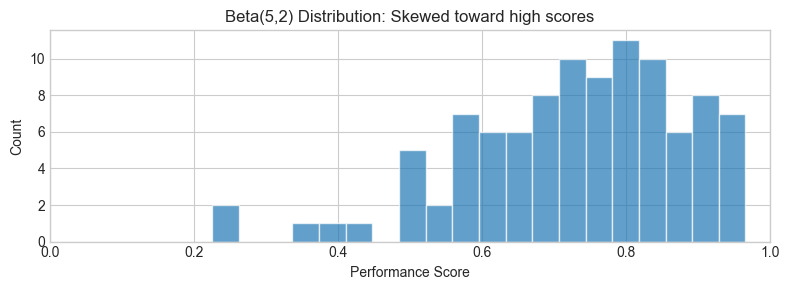

In [8]:
class PerformanceScore(BaseModel):
    employee_name: str
    score: Annotated[float, Beta(alpha=5, beta=2)]  # Skewed high (most perform well)

scores = await generate_synthetic_data(PerformanceScore, count=100, seed=42)

score_values = [s.score for s in scores]
print(f"Mean: {np.mean(score_values):.2f}")
print(f"Median: {np.median(score_values):.2f}")

# Plot
plt.figure()
plt.hist(score_values, bins=20, edgecolor='white', alpha=0.7)
plt.xlabel('Performance Score')
plt.ylabel('Count')
plt.title('Beta(5,2) Distribution: Skewed toward high scores')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Binomial Distribution

**Use for**: Success counts from a fixed number of trials (e.g., conversions from visits).

Parameters:
- `n`: Number of trials
- `p`: Probability of success on each trial

Expected: 5.0 conversions (5% of 100)
Mean: 5.3


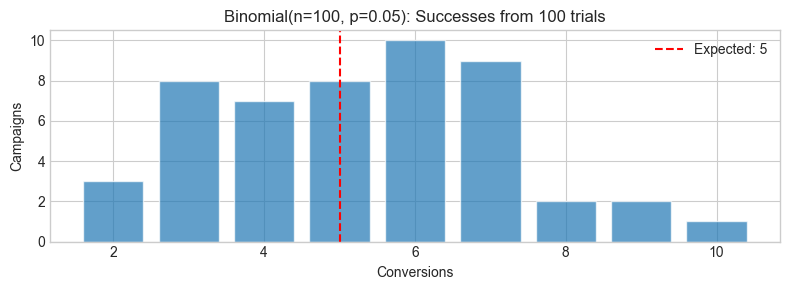

In [9]:
class ConversionData(BaseModel):
    campaign_name: str
    conversions: Annotated[int, Binomial(n=100, p=0.05)]  # 5% conversion rate from 100 visits

campaigns = await generate_synthetic_data(ConversionData, count=50, seed=42)

conversion_counts = [c.conversions for c in campaigns]
print(f"Expected: {100 * 0.05} conversions (5% of 100)")
print(f"Mean: {np.mean(conversion_counts):.1f}")

# Plot
plt.figure()
unique_counts = range(min(conversion_counts), max(conversion_counts) + 1)
frequencies = [conversion_counts.count(c) for c in unique_counts]
plt.bar(unique_counts, frequencies, edgecolor='white', alpha=0.7)
plt.axvline(5, color='red', linestyle='--', label='Expected: 5')
plt.xlabel('Conversions')
plt.ylabel('Campaigns')
plt.title('Binomial(n=100, p=0.05): Successes from 100 trials')
plt.legend()
plt.tight_layout()
plt.show()

## Combining Distributions in a Model

Use multiple distributions together with LLM-generated fields:

In [10]:
class SalesRecord(BaseModel):
    """Comprehensive sales record with various distribution types."""
    
    # LLM-generated
    customer_name: str
    product_name: str
    notes: str
    
    # Distribution-sampled
    deal_value: Annotated[float, LogNormal(mean=9, sigma=1.2)]  # Right-skewed
    units_sold: Annotated[int, Poisson(lam=5)]  # Count data
    discount_pct: Annotated[float, Beta(alpha=2, beta=8)]  # Mostly low discounts
    days_to_close: Annotated[int, Exponential(scale=14)]  # Wait time
    region: Annotated[str, Categorical(weights={
        "North": 0.30, 
        "South": 0.25, 
        "East": 0.25, 
        "West": 0.20
    })]

sales = await generate_synthetic_data(SalesRecord, count=5, seed=42)

for sale in sales:
    print(f"{sale.customer_name} - {sale.product_name}")
    print(f"  Value: £{sale.deal_value:,.0f} | Units: {sale.units_sold} | Discount: {sale.discount_pct:.1%}")
    print(f"  Region: {sale.region} | Days to close: {sale.days_to_close}")
    print(f"  Notes: {sale.notes[:60]}...")
    print()

John Doe - Smartphone X1
  Value: £11,680 | Units: 8 | Discount: 22.3%
  Region: East | Days to close: 19
  Notes: Closed deal efficiently, appreciated fast response....

Jane Smith - Tablet Z2
  Value: £2,326 | Units: 3 | Discount: 19.3%
  Region: South | Days to close: 21
  Notes: Customer showed strong interest in new features, follow-up s...

Michael Johnson - Laptop Pro 15
  Value: £19,941 | Units: 9 | Discount: 20.1%
  Region: North | Days to close: 74
  Notes: Negotiated terms effectively, potential for repeat business....

Emily Brown - Wireless Headphones 20
  Value: £25,051 | Units: 6 | Discount: 27.8%
  Region: South | Days to close: 29
  Notes: Discount was a decisive factor, check back for feedback afte...

David Wilson - Smartwatch 5
  Value: £780 | Units: 3 | Discount: 7.2%
  Region: North | Days to close: 23
  Notes: First-time buyer, provide additional product info to ensure ...



## Using Field Constraints with Distributions

Pydantic's `Field()` constraints can clip distribution samples to valid ranges:

In [11]:
class BoundedSalary(BaseModel):
    name: str
    # Normal distribution, but clipped to valid range
    salary: Annotated[float, Normal(mean=50000, std=20000)] = Field(ge=30000, le=150000)

bounded = await generate_synthetic_data(BoundedSalary, count=100, seed=42)

salaries = [b.salary for b in bounded]
print(f"Min: £{min(salaries):,.0f} (constrained >= £30,000)")
print(f"Max: £{max(salaries):,.0f} (constrained <= £150,000)")

Min: £30,000 (constrained >= £30,000)
Max: £92,833 (constrained <= £150,000)


## Distribution Selection Guide

| Data Type | Distribution | Example |
|-----------|-------------|--------|
| Measurements, scores | `Normal(mean, std)` | Salaries, heights |
| Bounded ranges | `Uniform(min, max)` | Ages, random IDs |
| Categories | `Categorical(weights)` | Departments, regions |
| Right-skewed values | `LogNormal(mean, sigma)` | Incomes, file sizes |
| Wait times | `Exponential(scale)` | Response times |
| Event counts | `Poisson(lam)` | Errors, arrivals |
| Probabilities (0-1) | `Beta(alpha, beta)` | Conversion rates |
| Success counts | `Binomial(n, p)` | Conversions from visits |